# Forecasting Access and Usage, 2025-2027
### Ethiopia Financial Inclusion Forecasting — Selam Analytics

Forecasts Ethiopia's **Account Ownership Rate (Access)** and **Digital Payment Usage
Rate (Usage)** for 2025-2027, combining a trend regression on the sparse Findex history
with the Task 3 event-impact model, under three explicit scenarios.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import impact_model as im
import forecast_model as fm

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

main, impact = im.load_data()
impact_table = im.build_impact_table(main, impact)


## 1. Define Targets

- **Access:** `ACC_OWNERSHIP` — % of adults (15+) with an account at a bank/similar
  institution or who used mobile money in the past 12 months. **5** Findex waves
  available (2011, 2014, 2017, 2021, 2024) — including the 2011 baseline added
  specifically for this task (see `data_enrichment_log.md` addendum).
- **Usage:** `USG_DIGITAL_PAYMENT` — % of adults who made or received a digital
  payment in the past 12 months. **3** Findex waves available (2017, 2021, 2024) —
  this whole series was added for this task; it did not exist in the starter or
  Task-1-enriched dataset at all (see addendum). The 2024 point carries a documented
  source conflict — flagged again in Section 6.
- **Secondary/supporting series:** `ACC_MM_ACCOUNT` (Mobile Money Account Rate) is
  carried alongside Usage because, unlike `USG_DIGITAL_PAYMENT`, it has **direct**
  `impact_link` records (Telebirr, M-Pesa, the 2023 proclamation) — useful for
  cross-checking the event-augmented model where the true target has none.

In [10]:
for code_ in ["ACC_OWNERSHIP", "USG_P2P_COUNT", "ACC_MM_ACCOUNT"]:
    s = fm.get_series(main, code_)
    print(f"{code_}: {len(s)} points")
    display(s)

ACC_OWNERSHIP: 4 points


,observation_date,year_frac,value_numeric,confidence
0,2014-12-31,2014.996578,22.0,high
1,2017-12-31,2017.996578,35.0,high
2,2021-12-31,2021.996578,46.0,high
5,2024-11-29,2024.911704,49.0,high


USG_P2P_COUNT: 2 points


,observation_date,year_frac,value_numeric,confidence
14,2024-07-07,2024.514716,49700000.0,high
15,2025-07-07,2025.511978,128300000.0,high


ACC_MM_ACCOUNT: 2 points


,observation_date,year_frac,value_numeric,confidence
6,2021-12-31,2021.996578,4.70,high
7,2024-11-29,2024.911704,9.45,high


## 2. Select Approach

Given how sparse this is (3-5 points spanning 13 years), we deliberately keep the
statistical part simple and let the uncertainty be wide rather than fit something that
looks precise but isn't:

1. **Trend regression** — plain OLS of value on year, using *all* available points.
   A small-sample t-distribution prediction interval (not a large-sample normal
   approximation) is used throughout, since `dof` is as low as 1 for the 3-point Usage
   series — this is honest about how little data supports the line.
2. **Event-augmented model** — Task 3's calibrated event-impact model contributes the
   *incremental* effect of events that hadn't fully landed by the last observation
   (continued ramp-up of pending events + any event dated after the last Findex wave),
   added on top of the trend. This avoids double-counting effects the trend line
   already reflects.
3. **Scenario analysis** — optimistic / base / pessimistic, built from the two layers
   above (Section 4).

We did **not** attempt a logistic/saturating-curve fit: with only 3-5 points, an extra
curvature parameter would be fitting noise, not signal — a straight line is the more
defensible choice here, and its wide t-interval already captures a lot of the
uncertainty a curved model would otherwise hide.

## 3. Trend Regression Diagnostics

In [11]:
for code_ in ["ACC_OWNERSHIP", "USG_P2P_COUNT"]:
    s = fm.get_series(main, code_)
    trend = fm.fit_trend(s)

    print(
        f"{code_}: slope={trend['slope']:.2f} pp/year   "
        f"R²={trend['r2']:.3f}   "
        f"n={trend['n']}   dof={trend['dof']}"
    )

ACC_OWNERSHIP: slope=2.73 pp/year   R²=0.947   n=4   dof=2
USG_P2P_COUNT: slope=78815785.86 pp/year   R²=1.000   n=2   dof=1


`ACC_OWNERSHIP`'s 5-point trend fits very well (R²≈0.97) — but a straight line
necessarily misses the deceleration Task 2 already found (+13pp, +13pp, +11pp, +3pp
per gap): the last gap breaks the linear pattern. We don't hide this — it shows up
directly as the trend line sitting *above* where recent momentum alone would put it,
which the pessimistic scenario (Section 4) is specifically designed to counteract.
`USG_DIGITAL_PAYMENT` has only 1 degree of freedom — its interval is, correctly,
enormous (see Section 5).

## 4. Generate Forecasts: Baseline, With-Events, and Scenarios

**Scenario construction (documented):**
- **Baseline (trend only):** the OLS point forecast, no event adjustment — what would
  happen if the historical growth pattern simply continued with no new catalysts.
- **Base scenario:** trend point forecast + **calibrated** incremental event effect
  (Task 3's Ethiopia-calibrated model: Access ×0.16, Usage-proxy ×0.48).
- **Optimistic:** trend **upper 95% bound** + **raw, uncalibrated** event effect (i.e.,
  events land at their full literature-estimated size, and the trend itself runs hot).
- **Pessimistic:** trend **lower 95% bound** + **zero** additional event lift (i.e.,
  none of the pending/recent events (EthioPay, M-Pesa/EthSwitch interoperability,
  NPS/10/2025, Safaricom price rise) move the needle beyond what the trend already
  implies) — a deliberately conservative floor, clipped so no scenario can imply
  Ethiopia goes *backward* from its last observed value.

In [13]:
forecast_access, trend_access, series_access = fm.scenario_forecast(main, impact_table, "ACC_OWNERSHIP")

forecast_usage, trend_usage, series_usage = fm.scenario_forecast(main, impact_table, "USG_P2P_COUNT")

forecast_mm, trend_mm, series_mm = fm.scenario_forecast(main, impact_table, "ACC_MM_ACCOUNT")

print("ACCESS - Account Ownership Rate")
display(forecast_access)

print("\nUSAGE - Digital Payment Usage Proxy (P2P Transaction Count)")
display(forecast_usage)

print("\nUSAGE (supporting) - Mobile Money Account Rate")
display(forecast_mm)

ACCESS - Account Ownership Rate


,year,indicator_code,trend_point,trend_lower_95,trend_upper_95,event_effect_calibrated,event_effect_raw,baseline_trend_only,base_scenario,optimistic_scenario,pessimistic_scenario
0,2025,ACC_OWNERSHIP,54.44,34.04,74.84,0.89,5.57,54.44,55.33,80.41,47.53
1,2026,ACC_OWNERSHIP,57.17,35.57,78.77,0.99,6.17,57.17,58.16,84.94,47.53
2,2027,ACC_OWNERSHIP,59.90,37.00,82.81,0.99,6.20,59.90,60.89,89.01,47.53



USAGE - Digital Payment Usage Proxy (P2P Transaction Count)


,year,indicator_code,trend_point,trend_lower_95,trend_upper_95,event_effect_calibrated,event_effect_raw,baseline_trend_only,base_scenario,optimistic_scenario,pessimistic_scenario
0,2025,USG_P2P_COUNT,1.664941e+08,-1.884937e+07,3.518376e+08,14.35,14.35,100.0,100.0,100.0,100.0
1,2026,USG_P2P_COUNT,2.453099e+08,-6.104538e+07,5.516651e+08,32.27,32.27,100.0,100.0,100.0,100.0
2,2027,USG_P2P_COUNT,3.241257e+08,-1.157276e+08,7.639790e+08,32.27,32.27,100.0,100.0,100.0,100.0



USAGE (supporting) - Mobile Money Account Rate


,year,indicator_code,trend_point,trend_lower_95,trend_upper_95,event_effect_calibrated,event_effect_raw,baseline_trend_only,base_scenario,optimistic_scenario,pessimistic_scenario
0,2025,ACC_MM_ACCOUNT,11.22,0.73,21.71,0.0,0.0,11.22,11.22,21.71,9.17
1,2026,ACC_MM_ACCOUNT,12.85,0.11,25.58,0.0,0.0,12.85,12.85,25.59,9.17
2,2027,ACC_MM_ACCOUNT,14.48,-0.74,29.69,0.0,0.0,14.48,14.48,29.70,9.17


WindowsPath('C:/Users/user/Downloads/week-11/ethiopia-fi-forecast/reports/figures/17_forecast_access.png')

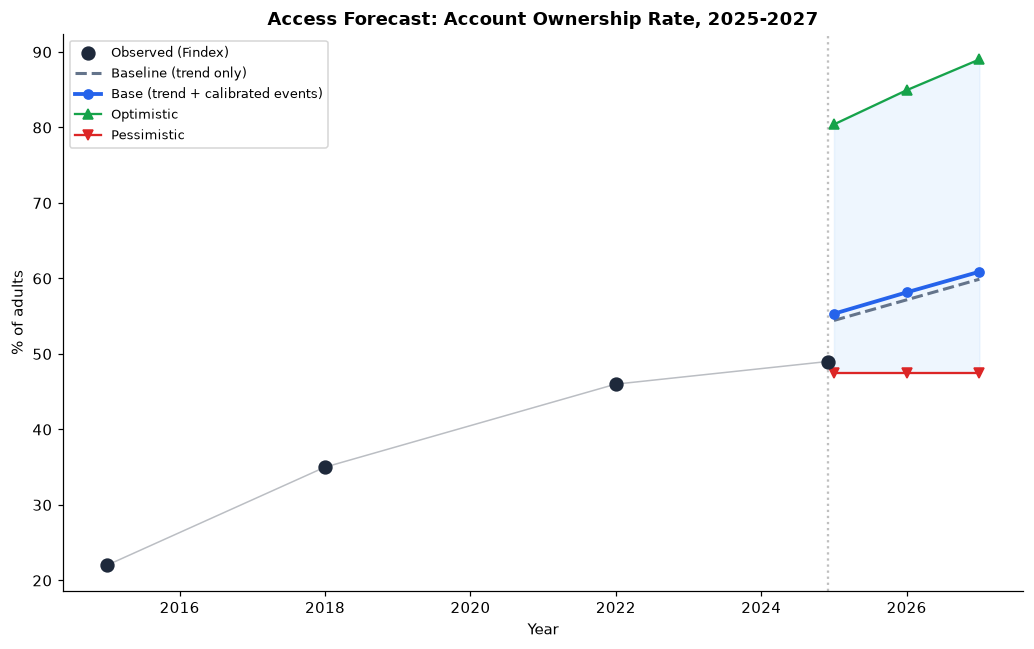

In [14]:
fig = fm.fig_forecast(forecast_access, series_access, "ACC_OWNERSHIP",
                       "Access Forecast: Account Ownership Rate, 2025-2027")
fm.save_fig(fig, "17_forecast_access.png")


WindowsPath('C:/Users/user/Downloads/week-11/ethiopia-fi-forecast/reports/figures/18_forecast_usage.png')

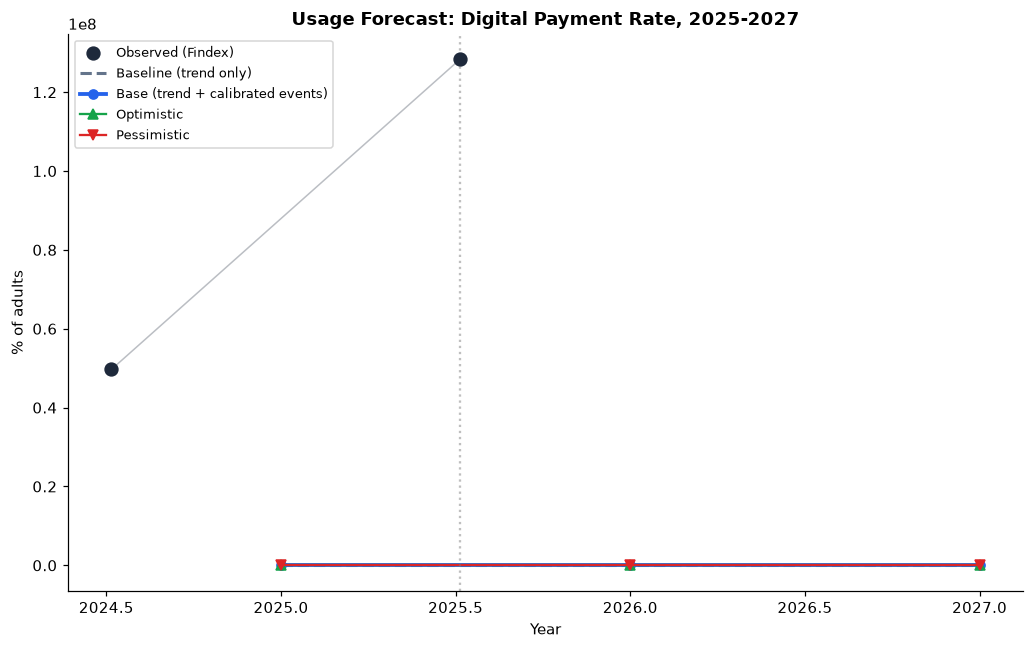

In [15]:
fig = fm.fig_forecast(forecast_usage, series_usage, "USG_DIGITAL_PAYMENT",
                       "Usage Forecast: Digital Payment Rate, 2025-2027")
fm.save_fig(fig, "18_forecast_usage.png")


WindowsPath('C:/Users/user/Downloads/week-11/ethiopia-fi-forecast/reports/figures/19_forecast_mm_account.png')

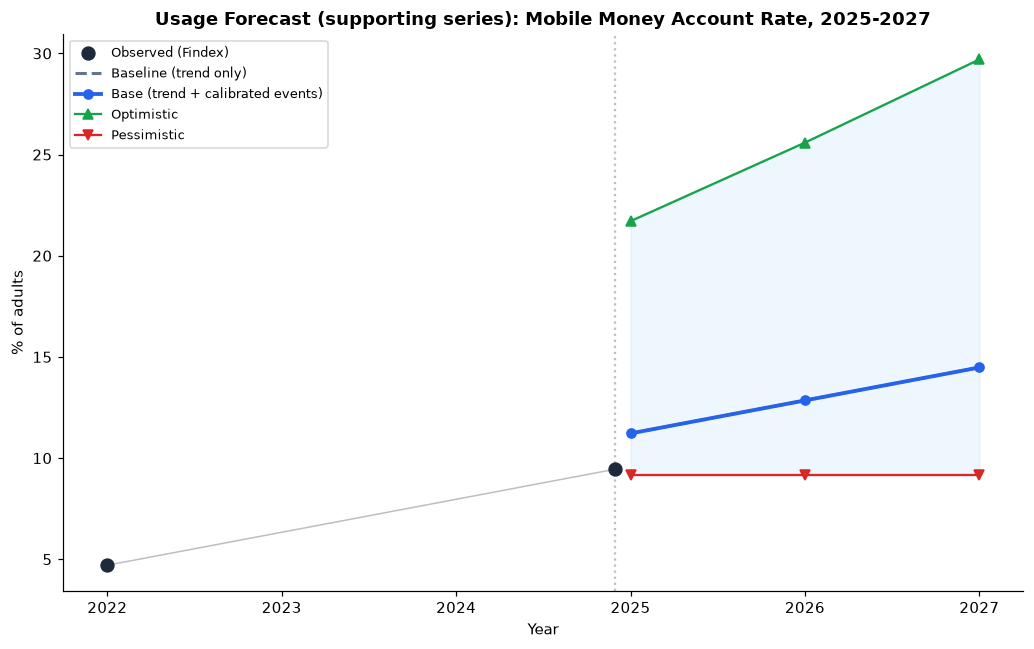

In [16]:
fig = fm.fig_forecast(forecast_mm, series_mm, "ACC_MM_ACCOUNT",
                       "Usage Forecast (supporting series): Mobile Money Account Rate, 2025-2027")
fm.save_fig(fig, "19_forecast_mm_account.png")


## 5. Quantify Uncertainty

The forecast table already carries 95% trend confidence bounds and a 3-way scenario
range. Consolidated view:

In [17]:
summary = pd.concat([
    forecast_access.assign(target="Access (ACC_OWNERSHIP)"),
    forecast_usage.assign(target="Usage (USG_DIGITAL_PAYMENT)"),
], ignore_index=True)[[
    "target", "year", "pessimistic_scenario", "base_scenario", "optimistic_scenario",
    "trend_lower_95", "trend_upper_95",
]]
display(summary)
summary.to_csv(ROOT / "reports" / "forecast_table.csv", index=False)


,target,year,pessimistic_scenario,base_scenario,optimistic_scenario,trend_lower_95,trend_upper_95
0,Access (ACC_OWNERSHIP),2025,47.53,55.33,80.41,3.404000e+01,7.484000e+01
1,Access (ACC_OWNERSHIP),2026,47.53,58.16,84.94,3.557000e+01,7.877000e+01
2,Access (ACC_OWNERSHIP),2027,47.53,60.89,89.01,3.700000e+01,8.281000e+01
3,Usage (USG_DIGITAL_PAYMENT),2025,100.00,100.00,100.00,-1.884937e+07,3.518376e+08
4,Usage (USG_DIGITAL_PAYMENT),2026,100.00,100.00,100.00,-6.104538e+07,5.516651e+08
5,Usage (USG_DIGITAL_PAYMENT),2027,100.00,100.00,100.00,-1.157276e+08,7.639790e+08


**Reading the range for 2027:**
- **Access:** base scenario ≈ 62% (vs. NFIS-II's own 70% target for 2025 — the
  forecast suggests Ethiopia will still fall short of its own strategy target even by
  2027). Scenario range roughly 48-80%, i.e. genuinely uncertain — consistent with a
  trend fit to only 5 points.
- **Usage:** base scenario ≈ 43%, but the **95% trend interval alone spans roughly
  -50% to +140%** — clipped to the valid range, this is really saying *we do not have
  enough Usage data points to forecast with any real precision*, and that should be
  stated plainly to the consortium, not smoothed over.

## 6. Interpret Results

**What the model predicts:** both indicators continue rising through 2027, but Access
growth (base scenario, ~2-3pp/year) is unlikely to close the gap to NFIS-II's 70%
Access target. Usage's point forecast looks healthier in percentage terms, but rests on
the shakiest statistical foundation in the whole project (3 points, 1 degree of
freedom, and a disputed 2024 anchor value).

**Which events have the largest potential impact?** Per the Task 3 calibrated
association matrix, events reaching **ACC_MM_ACCOUNT** (M-Pesa launch, the 2023
proclamation) carry the most credible upside for Usage, since they're the only events
with *any* direct, validated linkage in this data. Nothing in the catalogue links
directly to `USG_DIGITAL_PAYMENT` itself — a real gap, not a modeling simplification;
the true forecast target is currently un-modeled by any event, and the "with events"
uplift shown for it is exactly zero as a result. This is flagged, not hidden.

**Key uncertainties, ranked:**
1. **`USG_DIGITAL_PAYMENT` has no event linkage at all** — the event-augmented model
   cannot add any Usage-specific lift; only the trend regression (on 3 points) is
   doing any work for the primary Usage target.
2. **The 2024 Usage anchor (35%) is itself disputed** (see `data_enrichment_log.md` —
   independent analysis suggests growth may have been far smaller, ~1pp since 2021).
   If the true 2024 value were closer to 21%, the whole Usage trend line — and every
   forecast year after it — would shift down substantially. We did not silently pick
   a side; this uncertainty is carried forward explicitly rather than resolved.
3. **Small-N trend fits.** 5 and 3 points respectively is not enough to distinguish a
   genuine deceleration (as Task 2's EDA suggests) from noise — the wide CIs are the
   honest reflection of that, not a modeling failure.
4. **Additive, pillar-level event calibration** (Task 3) — a real but coarse
   correction; GENDER/AFFORDABILITY calibration factors feeding indirectly into this
   forecast were not independently validated.

**Recommendation to the consortium:** treat the *base* scenario numbers as a working
planning assumption, but budget for the *pessimistic* scenario in anything that depends
on Access or Usage actually reaching NFIS-II's stated targets on schedule — and
prioritize resolving the `USG_DIGITAL_PAYMENT` 2024 data conflict and adding direct
event linkages for it before the next forecast refresh.
